In [48]:
import torch
import torch.nn as nn
from collections import deque
import random
import torch.optim as optim
from ipynb.fs.defs.feature_engineering import monte_carlo_data
import pandas as pd
import numpy as np

from ipynb.fs.defs.q_network import QNetwork
from ipynb.fs.defs.agent import DQNAgent, ReplayBuffer 
from ipynb.fs.defs.trading_env import TradingEnv
   


In [51]:
#train_prices = monte_carlo_data("MSFT ","2020-01-01", "2024-01-01").squeeze()

#env = TradingEnv(train_prices)
agent = DQNAgent()

stocks = [
    "AAPL",
    "MSFT",
    "GOOG",
    "AMZN",
    "META"
]
reward_history = []
price_cache = {}

for ticker in stocks:
    price_cache[ticker] = monte_carlo_data(ticker,"2020-01-01","2024-01-01").squeeze()

feature_cache = {}

for ticker in stocks:

    prices = price_cache[ticker]

    df = pd.DataFrame(index=prices.index)

    # Price
    df["price"] = prices

    # Momentum (1-day return)
    df["momentum"] = prices.pct_change()

    # Volatility (10-day rolling std of returns)
    df["volatility"] = (
        prices.pct_change()
        .rolling(10)
        .std()
    )

    # MA Signal
    ma20 = prices.rolling(20).mean()
    df["ma_signal"] = (prices - ma20) / ma20

    df["return_20"] = prices.pct_change(20)
    df["return_50"] = prices.pct_change(50)

    ma50 = prices.rolling(50).mean()
    df["ma50_signal"] = (prices - ma50) / ma50
    ma200 = prices.rolling(200).mean()
    df["ma200_signal"] = (prices - ma200) / ma200

    df["atr_proxy"] = prices.pct_change().abs().rolling(14).mean()

    # RSI
    delta = prices.diff()

    gains = delta.clip(lower=0)
    losses = -delta.clip(upper=0)

    avg_gain = gains.rolling(14).mean()
    avg_loss = losses.rolling(14).mean()

    rs = avg_gain / avg_loss

    rsi = 100 - (100 / (1 + rs))

    df["rsi"] = rsi / 100.0

    # Fill early NaNs
    df = df.fillna(0)

    feature_cache[ticker] = df

for episode in range(400):
    
    ticker = random.choice(stocks)
    prices = price_cache[ticker]

    env = TradingEnv(feature_cache[ticker])
    state = env.reset()
    done = False
    episode_reward = 0
    while not done:

        action = agent.choose_action(state)

        next_state, reward, done = env.step(action)
        episode_reward += reward
        
        agent.replay_buffer.push((state, action, reward, next_state, done))

        agent.train_step()

        state = next_state
    reward_history.append(episode_reward) 
    agent.epsilon = max(agent.epsilon_min,agent.epsilon * agent.epsilon_decay)

    agent.update_target_net()
    print(
        f"Episode {episode+1} | "
        f"Reward: {episode_reward:.4f} | "
        f"Epsilon: {agent.epsilon:.4f}"
    )


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Episode 1 | Reward: 10711501.5894 | Epsilon: 0.9900
Episode 2 | Reward: 12456301.8887 | Epsilon: 0.9801
Episode 3 | Reward: 13065634.7464 | Epsilon: 0.9703
Episode 4 | Reward: 13488625.1956 | Epsilon: 0.9606
Episode 5 | Reward: 11062633.0172 | Epsilon: 0.9510
Episode 6 | Reward: 13473182.5688 | Epsilon: 0.9415
Episode 7 | Reward: 13452153.1151 | Epsilon: 0.9321
Episode 8 | Reward: 11250458.1820 | Epsilon: 0.9227
Episode 9 | Reward: 10310906.2783 | Epsilon: 0.9135
Episode 10 | Reward: 13790893.8585 | Epsilon: 0.9044
Episode 11 | Reward: 14329562.7414 | Epsilon: 0.8953
Episode 12 | Reward: 10776322.1760 | Epsilon: 0.8864
Episode 13 | Reward: 14695762.6737 | Epsilon: 0.8775
Episode 14 | Reward: 12504013.9315 | Epsilon: 0.8687
Episode 15 | Reward: 10890549.7739 | Epsilon: 0.8601
Episode 16 | Reward: 12873648.5763 | Epsilon: 0.8515
Episode 17 | Reward: 12380220.5395 | Epsilon: 0.8429
Episode 18 | Reward: 13723456.4303 | Epsilon: 0.8345
Episode 19 | Reward: 14668635.8817 | Epsilon: 0.8262
Ep

In [53]:
def evaluate_agent(agent, feature_df):

    env = TradingEnv(feature_df)

    state = env.reset()
    done = False

    portfolio_values = []
    actions_taken = []

    while not done:

        action = agent.choose_action(state)

        next_state, reward, done = env.step(action)

        portfolio_values.append(env.portfolio_value)
        actions_taken.append(action)

        state = next_state

    final_value = env.portfolio_value

    total_return = (
        final_value - env.initial_cash
    ) / env.initial_cash

    prices = feature_df["price"]

    buy_hold_return = (
        prices.iloc[-1] - prices.iloc[0]
    ) / prices.iloc[0]

    num_buys = (
        actions_taken.count(1)
        + actions_taken.count(2)
    )

    num_sells = (
        actions_taken.count(3)
        + actions_taken.count(4)
    )

    portfolio_values = np.array(portfolio_values)

    if len(portfolio_values) > 1:

        returns = (
            portfolio_values[1:]
            - portfolio_values[:-1]
        ) / portfolio_values[:-1]

        if returns.std() > 0:

            sharpe = (
                returns.mean()
                / returns.std()
            ) * np.sqrt(252)

        else:

            sharpe = 0

    else:

        sharpe = 0

    running_max = np.maximum.accumulate(
        portfolio_values
    )

    drawdowns = (
        portfolio_values - running_max
    ) / running_max

    max_drawdown = drawdowns.min()

    profits = env.trade_profits

    wins = [p for p in profits if p > 0]
    losses = [p for p in profits if p <= 0]

    if len(profits) == 0:

        win_rate = 0
        avg_win = 0
        avg_loss = 0
        profit_factor = 0

    else:

        win_rate = len(wins) / len(profits)

        avg_win = (
            sum(wins) / len(wins)
            if wins else 0
        )

        avg_loss = (
            sum(losses) / len(losses)
            if losses else 0
        )

        profit_factor = (
            sum(wins) / abs(sum(losses))
            if losses else float("inf")
        )

    print(f"Final Portfolio Value: ${final_value:.2f}")
    print(f"Strategy Return: {total_return*100:.2f}%")
    print(f"Buy & Hold Return: {buy_hold_return*100:.2f}%")
    print(f"Buys: {num_buys}")
    print(f"Sells: {num_sells}")

    print("Win Rate:", win_rate)
    print("Average Win:", avg_win)
    print("Average Loss:", avg_loss)
    print("Profit Factor:", profit_factor)
    print("Sharpe Ratio:", sharpe)
    print(
        "Max Drawdown:",
        f"{max_drawdown*100:.2f}%"
    )

    return {
        "final_value": final_value,
        "strategy_return": total_return,
        "buy_hold_return": buy_hold_return,
        "portfolio_values": portfolio_values,
        "actions": actions_taken,
        "sharpe": sharpe,
        "max_drawdown": max_drawdown,
        "win_rate": win_rate,
        "profit_factor": profit_factor
    }

In [59]:
test_stocks = [
    "AAPL",
    "MSFT",
    "GOOG",
    "AMZN",
    "META"
]

results_table = []

for ticker in test_stocks:

    prices = monte_carlo_data(ticker,"2024-01-01","2025-01-01").squeeze()

    df = pd.DataFrame(index=prices.index)

    df["price"] = prices
    df["momentum"] = prices.pct_change()
    df["volatility"] = prices.pct_change().rolling(10).std()

    ma20 = prices.rolling(20).mean()

    df["ma_signal"] = (prices - ma20) / ma20

    delta = prices.diff()
    gains = delta.clip(lower=0)
    losses = -delta.clip(upper=0)

    avg_gain = gains.rolling(14).mean()
    avg_loss = losses.rolling(14).mean()

    rs = avg_gain / avg_loss

    rsi = 100 - (100 / (1 + rs))

    df["rsi"] = rsi / 100.0

    df["return_20"] = prices.pct_change(20)

    df["return_50"] = prices.pct_change(50)
    
    ma50 = prices.rolling(50).mean()
    
    df["ma50_signal"] = (
        prices - ma50
    ) / ma50
    
    ma200 = prices.rolling(200).mean()
    
    df["ma200_signal"] = (
        prices - ma200
    ) / ma200
    
    df["atr_proxy"] = prices.pct_change().abs().rolling(14).mean()

    df = df.fillna(0)

    from collections import Counter

    res = evaluate_agent(agent, df)
    
    print(ticker)
    print(Counter(res["actions"]))
    
    results_table.append({
        "ticker": ticker,
        "strategy": res["strategy_return"],
        "buyhold": res["buy_hold_return"]
    })

for row in results_table:
    print(row)


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Final Portfolio Value: $13545.64
Strategy Return: 35.46%
Buy & Hold Return: 35.56%
Buys: 251
Sells: 0
Win Rate: 0
Average Win: 0
Average Loss: 0
Profit Factor: 0
Sharpe Ratio: 1.5149562924861082
Max Drawdown: -15.37%
AAPL
Counter({2: 251})
Final Portfolio Value: $11440.16
Strategy Return: 14.40%
Buy & Hold Return: 14.50%
Buys: 249
Sells: 0
Win Rate: 0
Average Win: 0
Average Loss: 0
Profit Factor: 0
Sharpe Ratio: 0.7887138324845985
Max Drawdown: -15.50%
MSFT
Counter({2: 249, 0: 2})
Final Portfolio Value: $13215.23
Strategy Return: 32.15%
Buy & Hold Return: 36.95%
Buys: 248
Sells: 3
Win Rate: 0.6666666666666666
Average Win: 0.12894841189650258
Average Loss: -0.05144893133495054
Profit Factor: 5.012676009031297
Sharpe Ratio: 1.1356509226182945
Max Drawdown: -22.29%
GOOG
Counter({2: 247, 4: 2, 3: 1, 1: 1})
Final Portfolio Value: $14511.25
Strategy Return: 45.11%
Buy & Hold Return: 46.33%
Buys: 249
Sells: 1
Win Rate: 1.0
Average Win: 0.24197969592742055
Average Loss: 0
Profit Factor: inf
Sh

KeyError: 'return_20'

In [46]:
import matplotlib.pyplot as plt
all_curves = []

for ticker in test_stocks:

    res = evaluate_agent(agent, prices)

    all_curves.append(
        np.array(res["portfolio_values"])
    )

avg_curve = np.mean(all_curves, axis=0)

plt.figure(figsize=(10,5))
plt.plot(avg_curve)
plt.title("Average Portfolio Value")
plt.show()

KeyError: 'price'

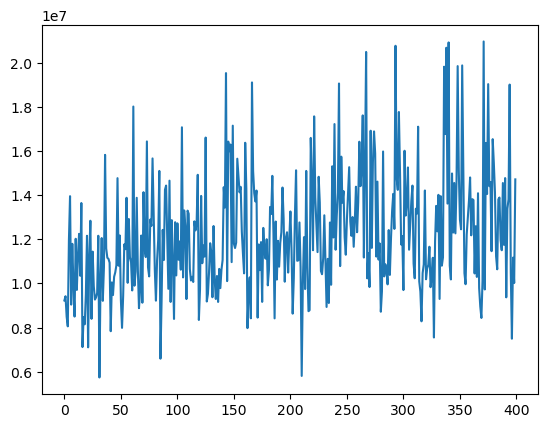

In [47]:
plt.plot(reward_history)
plt.show()

In [ ]:
print(env.valid_buys)
print(env.invalid_buys)